## Storm Chandra Presentation 2
Use hourly observation data from Met Éireann to make plots/comparisons.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

I opened the one of the files and the opening 41 lines tell the user about the different variables contained in the file. Here I will specify the columns I want. I am just going to focus on two variables, wind speed (sustained, not a gust) and mslp.

In [2]:
# columns to use
cols_to_use = [0, 2, 12] # 0: date, 2: rain, 12: wdsp

Write a convenient little function `load_met_csv` that opens the files, formats the dates, skips all the unwanted rows, tidies up the data into numerical form, etc.

In [3]:
def load_csv(file):
  df = pd.read_csv(file,
                      skiprows=41,
                      usecols=cols_to_use,
                      #index_col='date',
                      parse_dates=['date'],
                      date_format='%d-%b-%Y %H:%M',
                   low_memory=False)

  # match the columns
  df.columns = ['date', 'rain', 'wdsp']

  # make this into numerical data
  df['wdsp'] = pd.to_numeric(df['wdsp'], errors='coerce')
  df['wdsp_kmh'] = df['wdsp'] * 1.852 # changing wind speed to kmh
  df['rain'] = pd.to_numeric(df['rain'], errors='coerce')

  # Calculate 24-hour rolling rainfall totals
  df['rain_24h'] = df['rain'].rolling(24, min_periods=1).sum()

  return df

Creating a dictionary of all the files; I have a file from each chosen weather station that contains 30 years of hourly data, and I have a file from each weather station that has the hourly data from January this year (when Storm Chandra occurred).

In [6]:
stations = ['Dublin Airport', 'Valentia', 'Malin Head']

historical_data = {
    'Dublin Airport': '/home/ellen/Downloads/AIMSIR Semester 1/Physical Meteorology/phys-met/30-year-period_vs_chandra/dublin_airport_1995-2025.csv',
    'Valentia': '/home/ellen/Downloads/AIMSIR Semester 1/Physical Meteorology/phys-met/30-year-period_vs_chandra/valentia_1995-2025.csv',
    'Malin Head': '/home/ellen/Downloads/AIMSIR Semester 1/Physical Meteorology/phys-met/30-year-period_vs_chandra/malin_1995-2025.csv'

}

chandra_data = {
    'Dublin Airport': '/home/ellen/Downloads/AIMSIR Semester 1/Physical Meteorology/phys-met/30-year-period_vs_chandra/dublin_airport_jan-2026.csv',
    'Valentia': '/home/ellen/Downloads/AIMSIR Semester 1/Physical Meteorology/phys-met/30-year-period_vs_chandra/valentia_jan-2026.csv',
    'Malin Head': '/home/ellen/Downloads/AIMSIR Semester 1/Physical Meteorology/phys-met/30-year-period_vs_chandra/malin_jan-2026.csv'

}

I am creating a dictionary with different metrics; I want to find out the max wind speed at each station for the storm, for the last 30 years, and the 99th percentile etc.

In [7]:
metrics = {
    'station': [],
    'max_wind_chandra': [], 'max_wind_30yr': [], 'max_wind_p99': [],
    'max_rain_chandra': [], 'max_rain_30yr': [], 'max_rain_p99': []
}

for name in stations:
    df_hist = load_csv(historical_data[name])
    df_jan26 = load_csv(chandra_data[name])

    # 1. PROCESS BOTH DATAFRAMES EXPLICITLY
    processed_dfs = []
    for raw_df in [df_hist, df_jan26]:
        df = raw_df.sort_values('date').copy()

        # Resample hourly rain into official 09:00 UTC daily totals
        daily_rain = df.set_index('date')['rain'].resample('24h', offset='9h').sum().reset_index()
        daily_rain.rename(columns={'rain': 'rain_daily'}, inplace=True)

        # Merge back to the hourly dataframe
        df_merged = pd.merge_asof(df, daily_rain, on='date')
        processed_dfs.append(df_merged)

    # Re-assign back to df_hist and df_jan26
    df_hist, df_jan26 = processed_dfs[0], processed_dfs[1]

    # 2. FILTER DATASETS
    base_df = df_hist[(df_hist['date'] >= '1996-01-01') & (df_hist['date'] <= '2025-12-31')].copy()
    chandra_df = df_jan26[(df_jan26['date'] >= '2026-01-26') & (df_jan26['date'] <= '2026-01-28')].copy()

    # 3. FILTER EXTENDED STORM SEASON (October to March)
    storm_szn = base_df[base_df['date'].dt.month.isin([10, 11, 12, 1, 2, 3])]

    # 4. RECORD METRICS
    metrics['station'].append(name)

    # Wind Speed (km/h)
    max_wind_chan = chandra_df['wdsp_kmh'].max()
    max_wind_30yr = base_df['wdsp_kmh'].max()
    max_wind_p99  = storm_szn['wdsp_kmh'].quantile(0.99)

    metrics['max_wind_chandra'].append(max_wind_chan)
    metrics['max_wind_30yr'].append(max_wind_30yr)
    metrics['max_wind_p99'].append(max_wind_p99)

    # 24-Hour Official Daily Rainfall (mm) - Consistently using 'rain_daily'
    max_rain_chan = chandra_df['rain_daily'].max()
    max_rain_30yr = base_df['rain_daily'].max()
    max_rain_p99  = storm_szn['rain_daily'].quantile(0.99)

    metrics['max_rain_chandra'].append(max_rain_chan)
    metrics['max_rain_30yr'].append(max_rain_30yr)
    metrics['max_rain_p99'].append(max_rain_p99)

    # Diagnostics print check
    wind_date_30yr = base_df.loc[base_df['wdsp_kmh'].idxmax(), 'date'].strftime('%Y-%m-%d')
    rain_date_30yr = base_df.loc[base_df['rain_daily'].idxmax(), 'date'].strftime('%Y-%m-%d')

    print(f"=== {name} (Official 09:00 UTC Standard) ===")
    print(f"30-Yr Max Wind: {max_wind_30yr:.1f} km/h (on {wind_date_30yr})")
    print(f"30-Yr Max Daily Rain: {max_rain_30yr:.1f} mm (on {rain_date_30yr})")
    print(f"Chandra Peak Wind: {max_wind_chan:.1f} km/h | Chandra Peak Daily Rain: {max_rain_chan:.1f} mm\n")

# Combine results into pandas DataFrame
res = pd.DataFrame(metrics)

=== Dublin Airport (Official 09:00 UTC Standard) ===
30-Yr Max Wind: 83.3 km/h (on 2007-01-18)
30-Yr Max Daily Rain: 69.2 mm (on 2011-10-24)
Chandra Peak Wind: 48.2 km/h | Chandra Peak Daily Rain: 30.6 mm

=== Valentia (Official 09:00 UTC Standard) ===
30-Yr Max Wind: 105.6 km/h (on 1997-12-24)
30-Yr Max Daily Rain: 130.9 mm (on 2016-10-03)
Chandra Peak Wind: 53.7 km/h | Chandra Peak Daily Rain: 15.2 mm

=== Malin Head (Official 09:00 UTC Standard) ===
30-Yr Max Wind: 113.0 km/h (on 1998-12-26)
30-Yr Max Daily Rain: 73.0 mm (on 2017-08-22)
Chandra Peak Wind: 98.2 km/h | Chandra Peak Daily Rain: 14.7 mm



Now I need to visualise all of these results in some sort of clear way. Used Gemini.

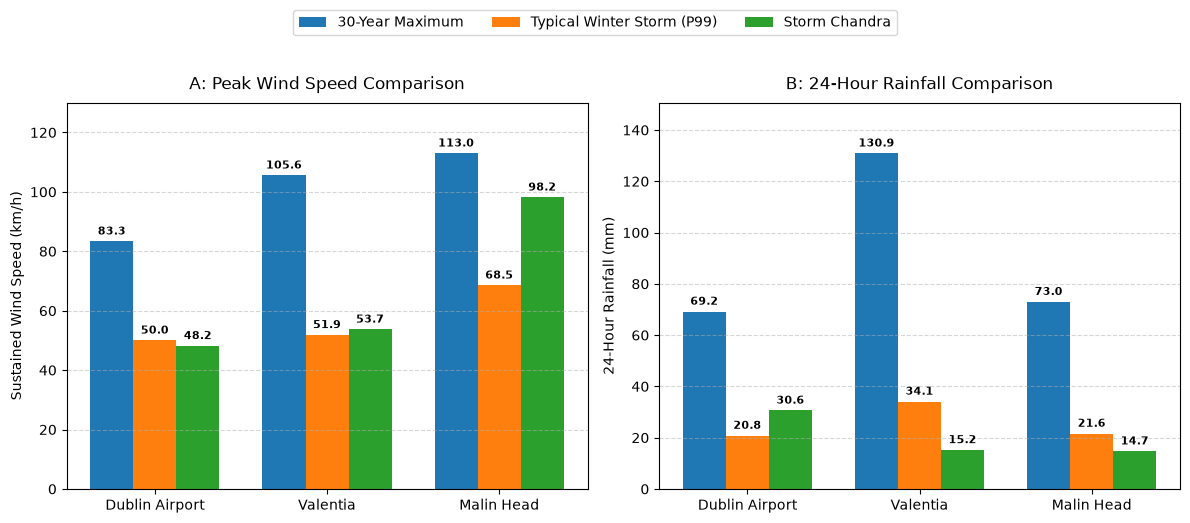

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(res['station']))
width = 0.25

# --- Panel 1: Peak Wind Speed ---
rects1 = ax1.bar(x - width, res['max_wind_30yr'], width, label='30-Year Maximum')
rects2 = ax1.bar(x,         res['max_wind_p99'],  width, label='Typical Winter Storm (P99)')
rects3 = ax1.bar(x + width, res['max_wind_chandra'], width, label='Storm Chandra')

ax1.set_ylabel('Sustained Wind Speed (km/h)')
ax1.set_title('A: Peak Wind Speed Comparison', pad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(res['station'])
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- Panel 2: Max Rainfall ---
rects4 = ax2.bar(x - width, res['max_rain_30yr'], width, label='30-Year Maximum')
rects5 = ax2.bar(x,         res['max_rain_p99'],  width, label='Typical Winter Storm (P99)')
rects6 = ax2.bar(x + width, res['max_rain_chandra'], width, label='Storm Chandra')

ax2.set_ylabel('24-Hour Rainfall (mm)')
ax2.set_title('B: 24-Hour Rainfall Comparison', pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(res['station'])

# Y-axis scaling for both panels (with upper padding for data labels)
max_wind_val = max(res['max_wind_30yr'].max(), res['max_wind_chandra'].max())
ax1.set_ylim(0, max_wind_val * 1.15)

max_rain_val = max(res['max_rain_30yr'].max(), res['max_rain_chandra'].max())
ax2.set_ylim(0, max_rain_val * 1.15)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# Annotations
def annotate_bars(ax, rects):
    for rect in rects:
        h = rect.get_height()
        if not np.isnan(h):
            ax.annotate(f"{h:.1f}",
                        xy=(rect.get_x() + rect.get_width() / 2, h),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=8, fontweight='bold')

annotate_bars(ax1, rects1)
annotate_bars(ax1, rects2)
annotate_bars(ax1, rects3)

annotate_bars(ax2, rects4)
annotate_bars(ax2, rects5)
annotate_bars(ax2, rects6)

# --- SHARED LEGEND SETUP ---
# Grab handles and labels from the first axis
handles, labels = ax1.get_legend_handles_labels()

# Add figure-level legend centered horizontally above the subplots
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, frameon=True)

# Adjust plot layout to ensure the legend isn't clipped
plt.tight_layout()
# Leave space at top for legend (and title if uncommented)
plt.subplots_adjust(top=0.85)

plt.show()